In [ ]:
!git clone https://github.com/AlexandreAronne/Linear-Regression---Interpretability.git


# Linear Regression for Asset Pricing (Weekly, Last 100 Weeks)

**Goal:** Introduce linear regression using classic asset pricing models in a practical, finance-oriented notebook.

We will:
- Download **daily** stock prices (Yahoo Finance), convert to **weekly** returns.
- Read **daily** factor returns from:
  - US: Fama–French 5 Factors (Ken French) — file: `F-F_Research_Data_5_Factors_2x3_daily.csv`
  - Brazil: NEFIN Factors — file: `nefin_factors.csv`  
    *First factor is `Rm_minus_Rf`; `rf` (risk-free) is the last column after `IML`. Values are already in decimals.*
- Convert factors to **weekly** via **compounding**.
- Use **excess returns** (stock − RF) as the dependent variable.
- Run three models for each stock:
  - **CAPM (1-factor):** MKT−RF
  - **FF3 (3-factors):** MKT−RF, SMB, HML
  - **5-factors:**  
    - **US (FF5):** MKT−RF, SMB, HML, RMW, CMA  
    - **BR (NEFIN 5):** MKT−RF, SMB, HML, WML (Momentum), IML (Illiquidity)
- Report **alpha, betas, t-stats, R², adj-R²** and show plots per instructions.

**Plotting rules:**
- Show **factor price-index** (base=100) **before** any stock output (**with legend**).
- For each stock, right after its name: plot **prices** and **returns** time series.
- **CAPM:** no exposure bar; **show** actual vs fitted.  
- **Multifactor (FF3, FF5/NEFIN5):** **show** exposure bar; **no** actual vs fitted.



## Learning objectives

1. Understand linear regression as used in empirical asset pricing.  
2. Map asset-pricing models (CAPM, FF3, FF5/NEFIN5) to regression form.  
3. Practice robust data handling (returns compounding, resampling, excess returns).  
4. Interpret regression outputs (alpha, betas, t-stats, R²).


In [ ]:
!pip install numpy pandas scikit-learn statsmodels matplotlib seaborn

In [ ]:

# If needed, install dependencies and auto-fix SciPy/statsmodels mismatch (_lazywhere issue)
import sys, subprocess

def _pip_install(pkgs):
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "pip", "install", *pkgs, "--quiet"])
    except Exception:
        subprocess.check_call([sys.executable, "-m", "pip", "install", *pkgs, "--quiet"])

try:
    import pandas as pd, numpy as np, matplotlib.pyplot as plt
    import statsmodels.api as sm
    import yfinance as yf
    from IPython.display import display
except Exception as e:
    msg = str(e)
    if "_lazywhere" in msg or "scipy._lib._util" in msg:
        _pip_install(["scipy<1.16", "statsmodels>=0.14.0"])
    else:
        _pip_install(["pandas","numpy","matplotlib","statsmodels","yfinance"])
    import pandas as pd, numpy as np, matplotlib.pyplot as plt, statsmodels.api as sm
    import yfinance as yf
    from IPython.display import display

pd.options.display.float_format = "{:,.4f}".format

# ---------------- Parameters ----------------
US_FACTORS_PATH = "Linear-Regression---Interpretability/F-F_Research_Data_5_Factors_2x3_daily.csv"  # Put this file next to the notebook
BR_FACTORS_PATH = "Linear-Regression---Interpretability/nefin_factors.csv"                          # Put this file next to the notebook

NEFIN_END_DATE = "2025-05-29"  # limit NEFIN data to this final date

SAMPLE_WEEKS = 100
WEEKLY_RULE  = "W-FRI"   # weekly data anchored on Fridays
HAC_LAGS     = 4         # NW HAC lags for weekly data

# Yahoo tickers
US_STOCKS = {
    "Tesla": "TSLA",
    "Apple": "AAPL",
    "McDonalds": "MCD",
    "Walmart": "WMT",
}

# Candidate tickers for Brazil (B3 tickers first, ADR/BDR fallbacks)
BR_STOCKS_CANDIDATES = {
    "Vale": ["VALE3.SA", "VALE", "VALE.SA"],
    "Petrobras": ["PETR4.SA", "PETR3.SA", "PBR", "PBR.A"],
    "BTG Pactual": ["BPAC11.SA", "BPAC5.SA", "BPAC3.SA", "BPAC"],
    "Inter": ["INBR32.SA", "BIDI11.SA", "BIDI4.SA", "BIDI3.SA", "INTR", "INBR"],
}

# download horizon fallback periods for price data
YF_DOWNLOAD_PERIODS = ["5y", "10y", "max"]

# Version print (helpful for debugging)
try:
    import scipy
    print("Versions -> pandas", pd.__version__,
          "| numpy", np.__version__,
          "| matplotlib", plt.matplotlib.__version__,
          "| scipy", scipy.__version__,
          "| statsmodels", sm.__version__)
except Exception:
    print("Versions -> pandas", pd.__version__,
          "| numpy", np.__version__,
          "| matplotlib", plt.matplotlib.__version__,
          "| statsmodels", sm.__version__)


Versions -> pandas 2.2.2 | numpy 2.0.2 | matplotlib 3.10.0 | scipy 1.16.3 | statsmodels 0.14.6



### Quick refresher: linear regression in asset pricing

We estimate regressions of the form

\[
R_{i,t} - R_{f,t} = \alpha_i + \beta_{i,\text{MKT}}(R_{m,t}-R_{f,t}) + \beta_{i,\text{SMB}} \text{SMB}_t + \beta_{i,\text{HML}} \text{HML}_t + \cdots + \varepsilon_{i,t}
\]

- **Dependent variable:** stock **excess return**.  
- **Regressors (factors):** market excess return and other factor returns.  
- **\(\alpha\):** abnormal return unexplained by the factors.  
- **\(\beta\):** factor loadings (sensitivities).  
We use HAC (Newey–West) standard errors to account for autocorrelation/heteroskedasticity in weekly returns.


In [ ]:

from typing import Dict, List, Tuple
import io, re
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

def _canon(s: str) -> str:
    """Uppercase and strip non-alphanumerics: 'Rm_minus_Rf' -> 'RMMINUSRF'."""
    return re.sub(r'[^A-Z0-9]+', '', str(s).upper())

def _standardize_date_index(df: pd.DataFrame) -> pd.DataFrame:
    possible = [c for c in df.columns if str(c).strip().lower() in ("date","data","dates")]
    date_col = possible[0] if possible else df.columns[0]
    try:
        idx = pd.to_datetime(df[date_col], errors="coerce")
    except Exception:
        idx = pd.to_datetime(df[date_col].astype(str), format="%Y%m%d", errors="coerce")
        if idx.isna().all():
            idx = pd.to_datetime(df[date_col], errors="coerce")
    df = df.copy()
    df.index = idx
    df.drop(columns=[date_col], inplace=True, errors="ignore")
    df = df.sort_index()
    df = df[~df.index.isna()]
    return df

def _add_rf_if_missing(df: pd.DataFrame) -> pd.DataFrame:
    """Ensure df has an 'RF' column by renaming NEFIN's 'rf' or common variants, or inferring from MKT and MKT_RF."""
    if "RF" in df.columns:
        return df
    rf_aliases = [c for c in df.columns if _canon(c) in {"RF","RFR","RISKFREE","SELIC","CDI"} or str(c).lower()=="rf"]
    if rf_aliases:
        df = df.rename(columns={rf_aliases[0]: "RF"})
        return df
    for mkt_name in ["MKT","RM","MARKET","IBOV","IBOVESPA","IBRX"]:
        if mkt_name in df.columns and "MKT_RF" in df.columns:
            df = df.copy()
            df["RF"] = df[mkt_name] - df["MKT_RF"]
            return df
    raise KeyError(f"[error] RF not found and cannot be inferred. Available columns: {list(df.columns)}")

def load_ff5_daily(path: str) -> pd.DataFrame:
    """
    Robust reader for Ken French FF5 daily CSVs that include header/footer text.
    Keeps only the data block, parses dates, standardizes column names, percent->decimal, ensures RF exists.
    """
    with open(path, "r", encoding="latin-1") as f:
        lines = f.readlines()

    header_idx = None
    for i, l in enumerate(lines[:500]):
        u = l.upper()
        if ("MKT" in u and "SMB" in u and "HML" in u) and ("," in l or ";" in l or "\t" in l):
            header_idx = i
            break

    if header_idx is None:
        df = pd.read_csv(path, engine="python", on_bad_lines="skip")
    else:
        df = pd.read_csv(io.StringIO("".join(lines[header_idx:])), engine="python")

    first = df.columns[0]
    s = df[first].astype(str).str.strip()
    dt = pd.to_datetime(s, format="%Y%m%d", errors="coerce")
    if dt.isna().all():
        dt = pd.to_datetime(s, errors="coerce")
    df = df.loc[~dt.isna()].copy()
    df.index = dt.loc[df.index]
    df.drop(columns=[first], inplace=True)

    # Map columns
    cmap = {}
    for c in df.columns:
        cl = _canon(c)
        if cl in {"MKTRF","MKTMINUSRF","MKTRFR"}: cmap[c] = "MKT_RF"
        elif cl == "SMB": cmap[c] = "SMB"
        elif cl == "HML": cmap[c] = "HML"
        elif cl == "RMW": cmap[c] = "RMW"
        elif cl == "CMA": cmap[c] = "CMA"
        elif cl in {"RF","RFR","RISKFREE"}: cmap[c] = "RF"
        elif cl in {"MKT","RM","MARKET"}: cmap[c] = "MKT"
    df = df.rename(columns=cmap)

    keep = [c for c in ["MKT","MKT_RF","SMB","HML","RMW","CMA","RF"] if c in df.columns]
    # FF data in PERCENT -> convert to decimals
    for c in keep:
        df[c] = pd.to_numeric(df[c], errors="coerce")/100.0
    df = _add_rf_if_missing(df)
    return df.dropna(how="all")

def load_nefin_daily(path: str) -> pd.DataFrame:
    """
    NEFIN daily CSV (Brazil):
      - First factor is 'Rm_minus_Rf' -> mapped to MKT_RF
      - 'IML' present
      - Last column is 'rf' (risk free) -> mapped to RF
    NOTE: Values are ALREADY IN DECIMALS (no /100 scaling).
    """
    try:
        df = pd.read_csv(path)
    except Exception:
        df = pd.read_csv(path, engine="python", on_bad_lines="skip")

    df = _standardize_date_index(df)

    cmap = {}
    for c in df.columns:
        cl = _canon(c)
        if cl in {"RMMINUSRF","MKTRF","MKTMINUSRF"} or str(c) == "Rm_minus_Rf":
            cmap[c] = "MKT_RF"
        elif cl == "SMB":
            cmap[c] = "SMB"
        elif cl == "HML":
            cmap[c] = "HML"
        elif cl in {"WML","MOM","UMD"}:
            cmap[c] = "WML"
        elif cl == "IML":
            cmap[c] = "IML"
        elif cl in {"RF","RFR","RISKFREE"} or str(c).lower()=="rf":
            cmap[c] = "RF"
        elif cl in {"MKT","RM","MARKET","IBOV","IBOVESPA","IBRX"}:
            cmap[c] = "MKT"
    df = df.rename(columns=cmap)

    keep = [c for c in ["MKT","MKT_RF","SMB","HML","WML","IML","RF"] if c in df.columns]
    # NEFIN ALREADY in decimals -> DO NOT scale by 100
    for c in keep:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df = _add_rf_if_missing(df)

    if "MKT_RF" not in df.columns:
        raise KeyError("[error] NEFIN: could not find 'Rm_minus_Rf' (MKT_RF).")

    return df[["MKT_RF","SMB","HML","WML","IML","RF"]].dropna(how="all")

def to_weekly_compound(df: pd.DataFrame, rule: str = "W-FRI") -> pd.DataFrame:
    """Compound daily returns to weekly: (1+r).resample(...).prod()-1."""
    df = df.sort_index()
    return (1.0 + df).resample(rule).prod() - 1.0

def to_price_index_from_returns(df: pd.DataFrame, base: float = 100.0) -> pd.DataFrame:
    """Convert return series to a price index: base * cumprod(1 + r)."""
    df = df.sort_index().copy()
    idx = (1.0 + df).cumprod()
    return base * idx

# ---- Resilient Yahoo download ----
def resolve_ticker(candidates: List[str]) -> str:
    """Pick the first candidate with enough 5y daily data."""
    import yfinance as yf
    for t in candidates:
        try:
            df = yf.download(t, period="5y", interval="1d", auto_adjust=True,
                             progress=False, threads=False)
            if df is not None and df.shape[0] > 200:
                return t
        except Exception:
            pass
    return candidates[0]

def download_prices_daily(ticker_map: Dict[str, str]):
    """
    Download each ticker separately (more reliable than multi-ticker calls),
    trying multiple periods. Returns (prices wide DF, map name->ticker that succeeded).
    """
    import yfinance as yf
    frames = []
    good = {}
    for name, t in ticker_map.items():
        s = None
        for per in ["5y", "10y", "max"]:
            try:
                df = yf.download(t, period=per, interval="1d", auto_adjust=True,
                                 progress=False, threads=False)
                if df is not None and df.shape[0] > 200:
                    s = (df["Adj Close"] if "Adj Close" in df.columns else df.iloc[:, 0]).rename(t).dropna()
                    break
            except Exception:
                pass
        if s is not None and s.size:
            frames.append(s)
            good[name] = t
        else:
            print(f"[warn] No usable data for {name} ({t})")
    prices = pd.concat(frames, axis=1) if frames else pd.DataFrame()
    return prices, good

def daily_prices_to_weekly_returns(prices_daily: pd.DataFrame, rule: str = "W-FRI") -> pd.DataFrame:
    """Compute weekly simple returns by compounding daily simple returns; drop thin series."""
    ret_d = prices_daily.pct_change()
    ret_w = (1.0 + ret_d).resample(rule).prod() - 1.0
    ret_w = ret_w.dropna(how="all")
    keep = [c for c in ret_w.columns if ret_w[c].dropna().shape[0] >= 30]
    return ret_w[keep]

# ---- Regression helpers + stock plots ----
def run_ols_hac(y: pd.Series, X: pd.DataFrame, lags: int = 4):
    """OLS with constant and HAC (Newey–West) SE."""
    Xc = sm.add_constant(X)  # const -> alpha
    model = sm.OLS(y, Xc, missing="drop")
    return model.fit(cov_type="HAC", cov_kwds={"maxlags": lags})

def summarize_result(res) -> pd.DataFrame:
    """Return a clean table with coef, t-stat + R2, Adj R2 rows."""
    params = res.params.rename(index={"const":"alpha"})
    tvals  = res.tvalues.rename(index={"const":"alpha"})
    order = ["alpha"] + [c for c in params.index if c != "alpha"]
    table = pd.DataFrame({
        "coef": params.reindex(order),
        "t-stat": tvals.reindex(order)
    })
    table.loc["R^2", "coef"] = res.rsquared
    table.loc["Adj R^2", "coef"] = res.rsquared_adj
    return table

def plot_exposures_bar(res, title: str):
    fig, ax = plt.subplots()
    params = res.params.rename(index={"const":"alpha"})
    betas = params[[c for c in params.index if c != "alpha"]]
    betas.plot(kind="bar", ax=ax)  # Matplotlib only; no explicit colors
    ax.set_ylabel("Loading (beta)")
    ax.set_title(title)
    plt.show()

def plot_actual_vs_fitted(y, fitted, title: str):
    fig, ax = plt.subplots()
    ax.scatter(fitted, y, alpha=0.7)
    # Regression line (actual on fitted)
    b1, b0 = np.polyfit(fitted.values, y.values, deg=1)
    xs = np.linspace(fitted.min(), fitted.max(), 100)
    ax.plot(xs, b1*xs + b0)
    ax.set_xlabel("Fitted excess return")
    ax.set_ylabel("Actual excess return")
    ax.set_title(title)
    plt.show()

def plot_prices_weekly(prices_daily: pd.Series, index_weeks: pd.DatetimeIndex, title: str, rule: str):
    """Resample daily prices to weekly (last) and plot over index_weeks."""
    px_w = prices_daily.resample(rule).last().loc[index_weeks]
    fig, ax = plt.subplots()
    ax.plot(px_w.index, px_w.values)
    ax.set_title(title)
    ax.set_ylabel("Price")
    ax.set_xlabel("Date")
    plt.show()

def plot_returns_weekly(ret_w: pd.Series, index_weeks: pd.DatetimeIndex, title: str):
    rw = ret_w.loc[index_weeks]
    fig, ax = plt.subplots()
    ax.plot(rw.index, rw.values)
    ax.set_title(title)
    ax.set_ylabel("Return")
    ax.set_xlabel("Date")
    plt.show()



## Load factor data (daily → weekly)

- FF5 (US) CSV is in **percent** → convert to **decimals** (÷100).  
- NEFIN (BR) CSV values are **already in decimals** → **no rescaling**.  
- NEFIN usage limited to **May 29, 2025** as the most recent date.  
- Compound **daily → weekly** using \((1+r)\_{\text{week}}=\prod_{d\in \text{week}}(1+r_d)-1\).


In [ ]:

ff5_daily = load_ff5_daily(US_FACTORS_PATH)

nefin_daily = load_nefin_daily(BR_FACTORS_PATH)
# Limit NEFIN data to 2025-05-29 (inclusive)
limit_date = pd.to_datetime(NEFIN_END_DATE)
nefin_daily = nefin_daily.loc[:limit_date]

ff5_weekly   = to_weekly_compound(ff5_daily, WEEKLY_RULE)
nefin_weekly = to_weekly_compound(nefin_daily, WEEKLY_RULE)

print("US FF5 weekly columns:", list(ff5_weekly.columns))
print("BR NEFIN weekly columns:", list(nefin_weekly.columns))


US FF5 weekly columns: ['MKT_RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF']
BR NEFIN weekly columns: ['MKT_RF', 'SMB', 'HML', 'WML', 'IML', 'RF']



## Stock prices → weekly returns

- Download **daily** prices from Yahoo Finance (robust single-ticker downloads).  
- Convert to **weekly** simple returns via compounding daily returns.  
- For Brazil, we try multiple ticker candidates and pick the first with sufficient data.


In [ ]:

# US tickers (direct)
us_tickers = US_STOCKS.copy()
us_prices_daily, us_ok = download_prices_daily(us_tickers)
us_ret_weekly = daily_prices_to_weekly_returns(us_prices_daily, WEEKLY_RULE)
print("US weekly returns:", us_ret_weekly.shape, "| columns:", list(us_ret_weekly.columns))
print("US tickers that downloaded:", us_ok)

# BR tickers (resolve from candidates using 5y data)
br_tickers = {name: resolve_ticker(cands) for name, cands in BR_STOCKS_CANDIDATES.items()}
print("Resolved BR tickers:", br_tickers)

br_prices_daily, br_ok = download_prices_daily(br_tickers)
br_ret_weekly = daily_prices_to_weekly_returns(br_prices_daily, WEEKLY_RULE)
print("BR weekly returns:", br_ret_weekly.shape, "| columns:", list(br_ret_weekly.columns))
print("BR tickers that downloaded:", br_ok)

# Note: per request, do NOT display tables of US/BR returns.


US weekly returns: (261, 4) | columns: ['TSLA', 'AAPL', 'MCD', 'WMT']
US tickers that downloaded: {'Tesla': 'TSLA', 'Apple': 'AAPL', 'McDonalds': 'MCD', 'Walmart': 'WMT'}
Resolved BR tickers: {'Vale': 'VALE3.SA', 'Petrobras': 'PETR4.SA', 'BTG Pactual': 'BPAC11.SA', 'Inter': 'INBR32.SA'}
BR weekly returns: (261, 4) | columns: ['VALE3.SA', 'PETR4.SA', 'BPAC11.SA', 'INBR32.SA']
BR tickers that downloaded: {'Vale': 'VALE3.SA', 'Petrobras': 'PETR4.SA', 'BTG Pactual': 'BPAC11.SA', 'Inter': 'INBR32.SA'}



## Regressions (CAPM, FF3, 5-Factors)

**Dependent:** \(R_{i,t} - RF_t\) (excess stock return).  
**Regressors:**
- CAPM: `MKT_RF`
- FF3: `MKT_RF`, `SMB`, `HML`
- 5-Factors:  
  - US FF5: `MKT_RF`, `SMB`, `HML`, `RMW`, `CMA`  
  - BR NEFIN5: `MKT_RF`, `SMB`, `HML`, `WML`, `IML`


In [ ]:

def run_models_for_stock(ret_w: pd.Series, factors_w: pd.DataFrame, geo: str):
    """
    Return dict model_name -> (result, y, X) using last SAMPLE_WEEKS after inner join.
    Models:
      US: CAPM, FF3, FF5
      BR: CAPM, FF3, NEFIN5
    """
    df = pd.concat([ret_w.rename("RET"), factors_w], axis=1, join="inner").dropna()
    if df.shape[0] < SAMPLE_WEEKS:
        print(f"[note] Only {df.shape[0]} aligned weeks available; using all.")
    df = df.iloc[-SAMPLE_WEEKS:].copy()
    if "RF" not in df.columns:
        raise KeyError("[error] 'RF' not present in factor data after alignment.")
    y = df["RET"] - df["RF"]

    if geo == "US":
        models = {
            "CAPM": ["MKT_RF"],
            "FF3": ["MKT_RF","SMB","HML"],
            "FF5": ["MKT_RF","SMB","HML","RMW","CMA"],
        }
    else:
        models = {
            "CAPM": ["MKT_RF"],
            "FF3": ["MKT_RF","SMB","HML"],
            "NEFIN5": ["MKT_RF","SMB","HML","WML","IML"],
        }

    out = {}
    for name, cols in models.items():
        missing = [c for c in cols if c not in df.columns]
        if missing:
            print(f"[warn] Skipping {name}: missing factors {missing}")
            continue
        X = df[cols].copy().dropna()
        y_ = y.loc[X.index]
        if len(X) < 25:
            print(f"[warn] Not enough observations for {name} ({len(X)}). Skipping.")
            continue
        res = run_ols_hac(y_, X, lags=HAC_LAGS)
        out[name] = (res, y_, X)
    return out

# US stocks
us_results = {}
for name, ticker in us_ok.items():
    if ticker in us_ret_weekly.columns:
        res = run_models_for_stock(us_ret_weekly[ticker].dropna(), ff5_weekly, "US")
        if res:
            us_results[name] = res

# BR stocks
br_results = {}
for name, ticker in br_ok.items():
    if ticker in br_ret_weekly.columns:
        res = run_models_for_stock(br_ret_weekly[ticker].dropna(), nefin_weekly, "BR")
        if res:
            br_results[name] = res

print("US stocks processed:", list(us_results.keys()))
print("BR stocks processed:", list(br_results.keys()))


US stocks processed: ['Tesla', 'Apple', 'McDonalds', 'Walmart']
BR stocks processed: ['Vale', 'Petrobras', 'BTG Pactual', 'Inter']



## Factor overview (weekly price index, base = 100)

We transform weekly factor returns into a **price index** starting at 100:
\[
P_t = 100 \times \prod_{k \le t} (1 + r_k).
\]


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

def plot_factor_effects(res, title="Factor Effects (FF5)"):
    """
    Plot *effects* (average weekly contribution of each factor to fitted returns)
    for a multifactor linear model result (statsmodels RegressionResults).

    Effect for factor j = E[ beta_j * X_j ] over the regression sample.
    Shows a bar chart with error bars (+/- 1 std of beta_j * X_j).
    Only runs when exactly five recognized factors are present.
    """
    model = res.model
    if hasattr(model, "data") and getattr(model.data, "orig_exog", None) is not None:
        X = model.data.orig_exog.copy()
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X, columns=model.exog_names)
        if getattr(model.data, "row_labels", None) is not None:
            try:
                X.index = pd.Index(model.data.row_labels)
            except Exception:
                pass
    else:
        X = pd.DataFrame(model.exog, columns=model.exog_names)

    drop_cols = [c for c in X.columns if str(c).lower() in ("const","intercept","alpha")]
    Xf = X.drop(columns=drop_cols, errors="ignore")
    beta = res.params.reindex(Xf.columns).dropna()
    Xf = Xf[beta.index]

    canon = lambda s: re.sub(r'[^a-z0-9]+', '', str(s).lower())
    known_ff5 = {"mktrf","smb","hml","rmw","cma"}
    cols_canon = {canon(c): c for c in Xf.columns}
    if len(beta) == 5:
        pass
    elif known_ff5.issubset(set(cols_canon.keys())):
        ordered = [cols_canon[k] for k in ("mktrf","smb","hml","rmw","cma")]
        beta = beta.reindex(ordered).dropna()
        Xf = Xf[beta.index]
    else:
        print("[info] Effect plot skipped (requires exactly 5 factors).")
        return

    contrib_ts = Xf.multiply(beta.values, axis=1)
    means_pct = contrib_ts.mean() * 100.0
    stds_pct = contrib_ts.std() * 100.0

    plt.figure()
    idx = np.arange(len(means_pct))
    plt.bar(idx, means_pct.values, yerr=stds_pct.values, capsize=3)
    plt.xticks(idx, [str(c) for c in means_pct.index])
    plt.ylabel("Average weekly contribution (% points)")
    plt.title(title if title else "Factor Effects (average β·factor)")
    plt.tight_layout()
    plt.show()


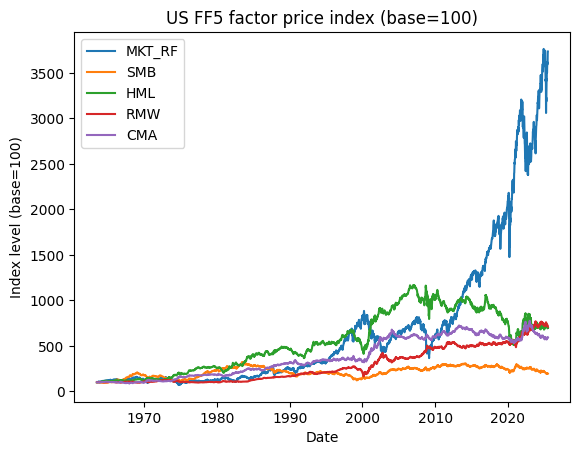

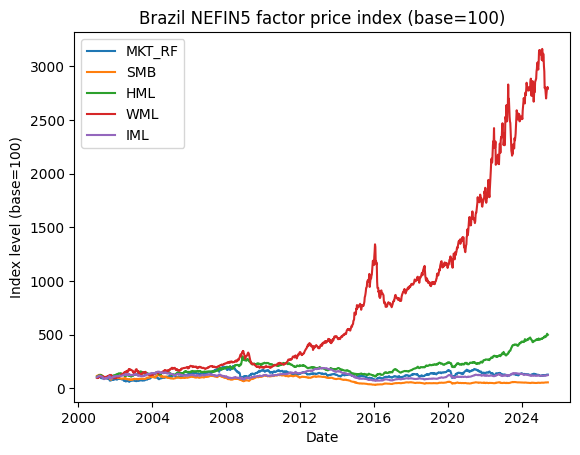

In [ ]:

# US FF5: build price index for the five factors
us_cols = [c for c in ["MKT_RF","SMB","HML","RMW","CMA"] if c in ff5_weekly.columns]
if us_cols:
    us_index = to_price_index_from_returns(ff5_weekly[us_cols], base=100.0)
    fig, ax = plt.subplots()
    ax.plot(us_index.index, us_index[us_cols])
    ax.set_title("US FF5 factor price index (base=100)")
    ax.set_xlabel("Date")
    ax.set_ylabel("Index level (base=100)")
    ax.legend(us_cols)
    plt.show()

# BR NEFIN5: build price index for the five factors (NEFIN capped at 2025-05-29)
br_cols = [c for c in ["MKT_RF","SMB","HML","WML","IML"] if c in nefin_weekly.columns]
if br_cols:
    br_index = to_price_index_from_returns(nefin_weekly[br_cols], base=100.0)
    fig, ax = plt.subplots()
    ax.plot(br_index.index, br_index[br_cols])
    ax.set_title("Brazil NEFIN5 factor price index (base=100)")
    ax.set_xlabel("Date")
    ax.set_ylabel("Index level (base=100)")
    ax.legend(br_cols)
    plt.show()



## Results: tables & plots

For each stock × model:
- **Table:** alpha, betas, t-stats, R², adj-R²  
- **Per-stock intro:** immediately after the stock name, we plot **prices** and **returns** time series.  
- **CAPM:** no exposure bar chart; **show** actual vs fitted.  
- **Multifactor (FF3, FF5/NEFIN5):** **show** exposure bar chart; no actual vs fitted.

*(Matplotlib only; one plot per figure; no explicit colors.)*



=== Tesla (TSLA) ===


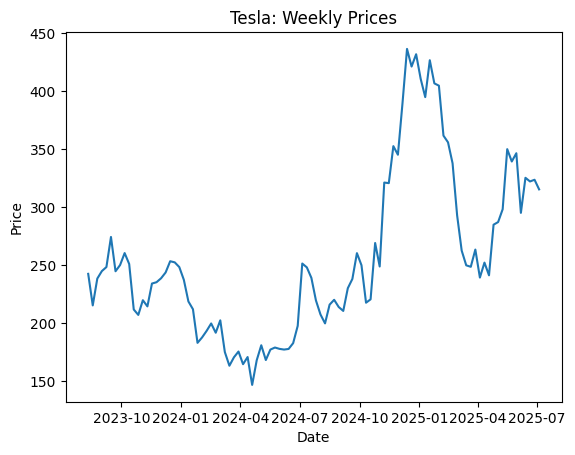

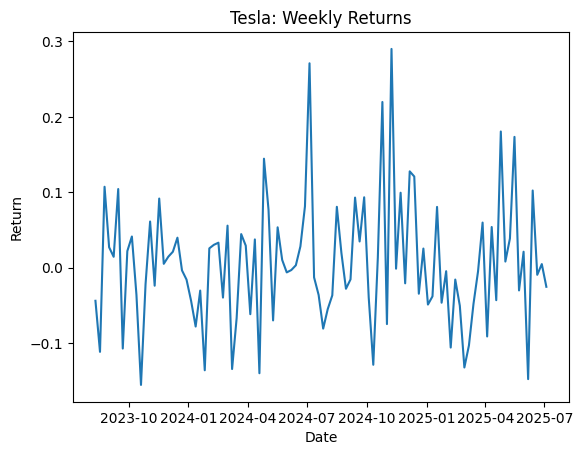


--- Model: CAPM ---


,coef,t-stat
alpha,-0.0006,-0.0830
MKT_RF,1.8654,5.8606
R^2,0.2513,NaN
Adj R^2,0.2437,NaN


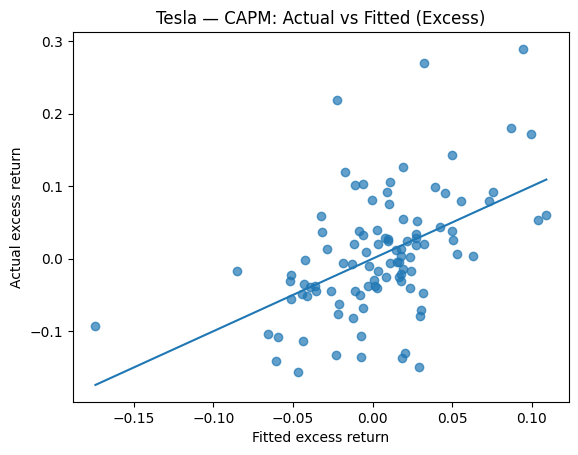


--- Model: FF3 ---


,coef,t-stat
alpha,0.0002,0.0212
MKT_RF,1.7343,5.8968
SMB,0.1813,0.3441
HML,-0.6382,-1.2592
R^2,0.2626,NaN
Adj R^2,0.2396,NaN


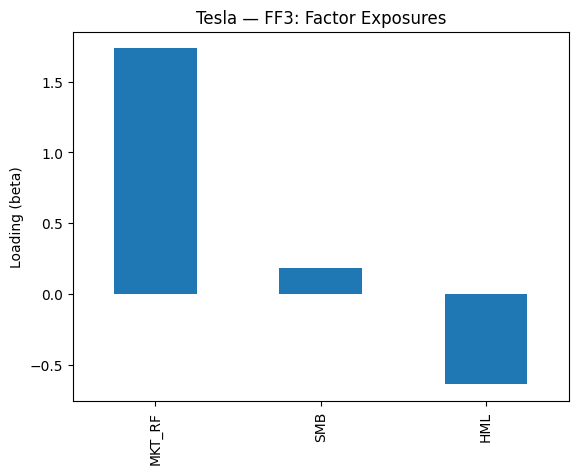


--- Model: FF5 ---


,coef,t-stat
alpha,-0.0027,-0.4235
MKT_RF,1.7951,6.1374
SMB,0.2627,0.5701
HML,-0.3206,-0.6658
RMW,-0.4416,-0.7897
CMA,-2.8086,-3.1985
R^2,0.3489,NaN
Adj R^2,0.3143,NaN


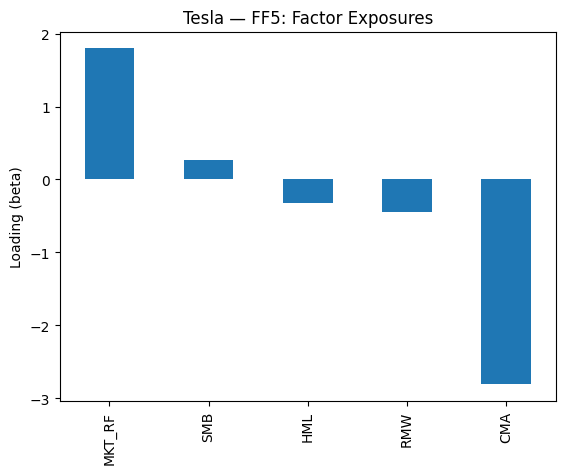


=== Apple (AAPL) ===


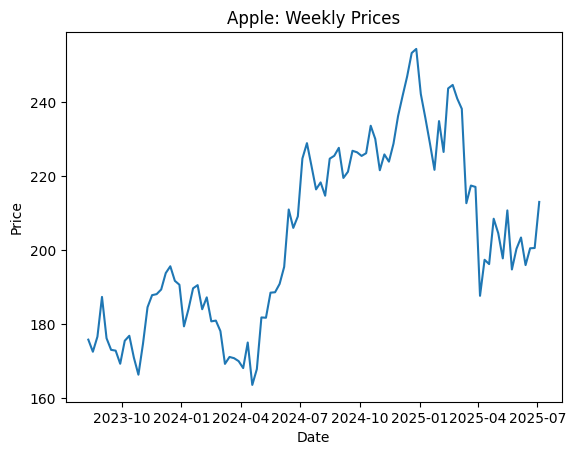

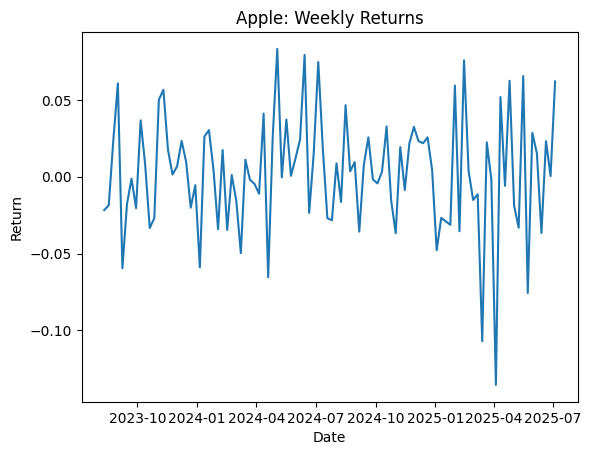


--- Model: CAPM ---


,coef,t-stat
alpha,-0.0013,-0.4759
MKT_RF,1.0095,7.8500
R^2,0.3639,NaN
Adj R^2,0.3574,NaN


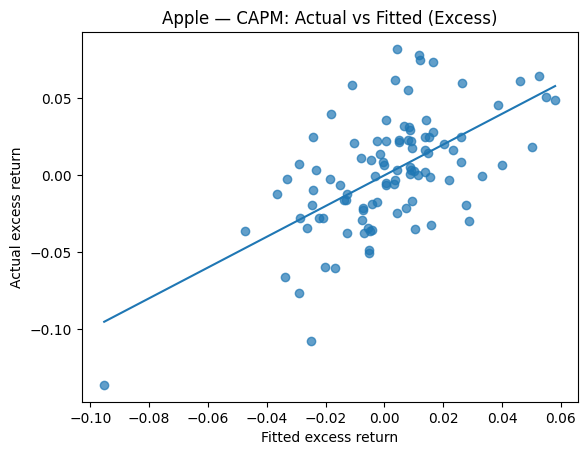


--- Model: FF3 ---


,coef,t-stat
alpha,-0.0016,-0.5456
MKT_RF,0.9546,7.3131
SMB,-0.1611,-0.8871
HML,-0.4339,-1.9110
R^2,0.4129,NaN
Adj R^2,0.3945,NaN


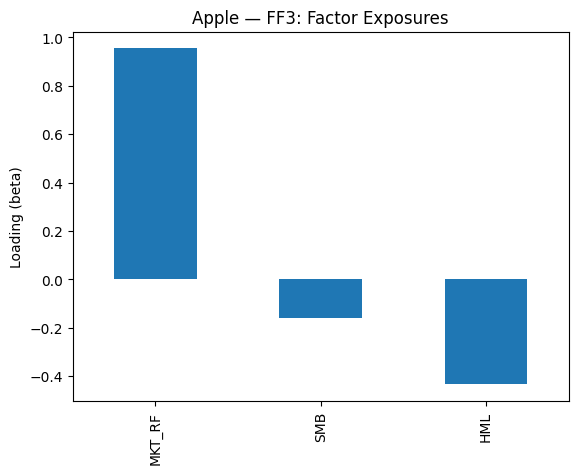


--- Model: FF5 ---


,coef,t-stat
alpha,-0.0019,-0.6774
MKT_RF,1.0635,5.7130
SMB,0.0260,0.1099
HML,-0.4313,-1.9525
RMW,0.4444,1.1636
CMA,-0.3999,-1.3604
R^2,0.4369,NaN
Adj R^2,0.4070,NaN


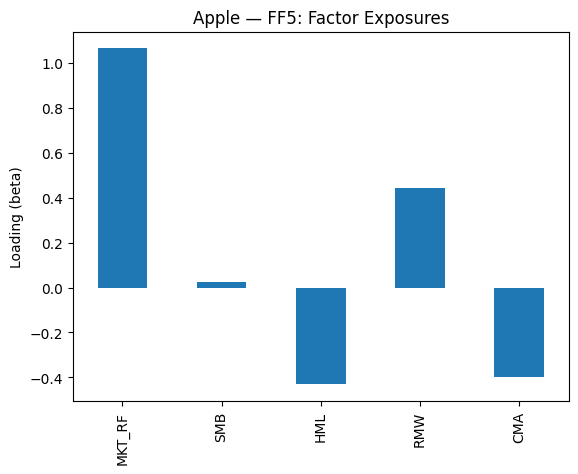


=== McDonalds (MCD) ===


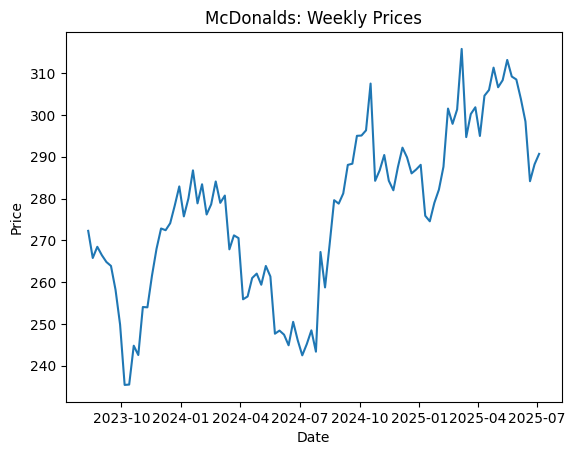

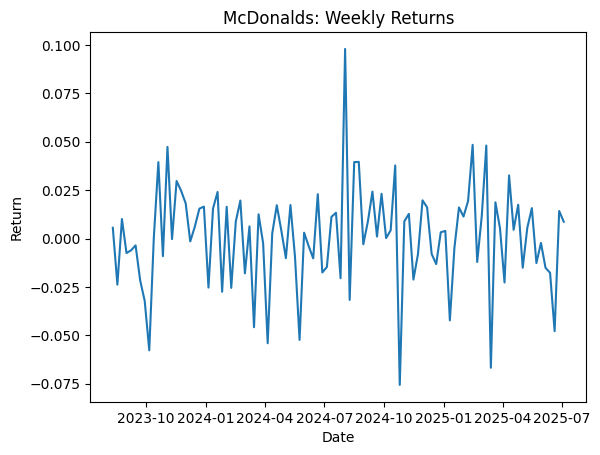


--- Model: CAPM ---


,coef,t-stat
alpha,-0.0008,-0.2981
MKT_RF,0.3104,3.9237
R^2,0.0716,NaN
Adj R^2,0.0621,NaN


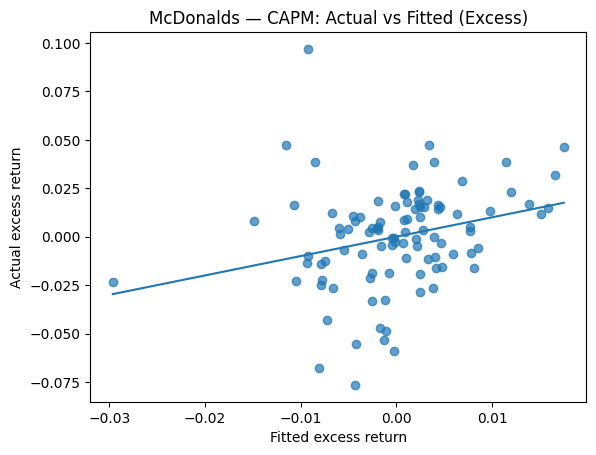


--- Model: FF3 ---


,coef,t-stat
alpha,-0.0006,-0.2477
MKT_RF,0.3122,3.9743
SMB,0.0652,0.3936
HML,0.0562,0.3705
R^2,0.0757,NaN
Adj R^2,0.0468,NaN


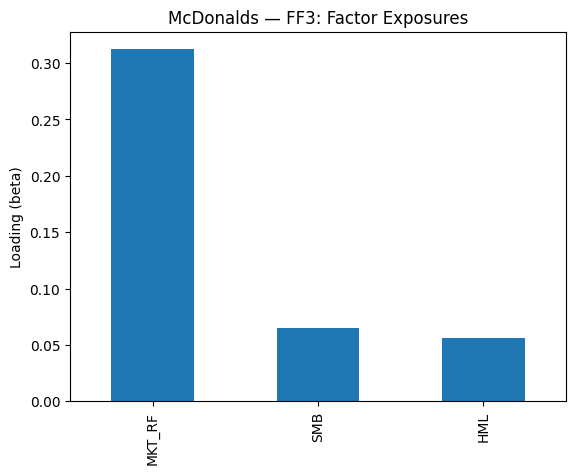


--- Model: FF5 ---


,coef,t-stat
alpha,0.0002,0.0989
MKT_RF,0.3603,4.5933
SMB,0.1563,0.8171
HML,-0.0588,-0.3590
RMW,0.4497,1.0211
CMA,0.7732,2.7782
R^2,0.1497,NaN
Adj R^2,0.1044,NaN


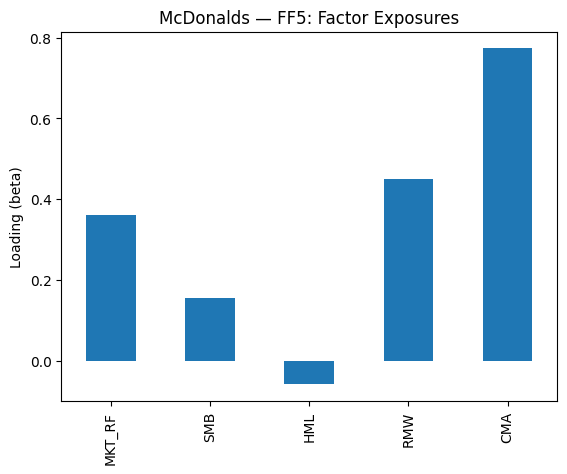


=== Walmart (WMT) ===


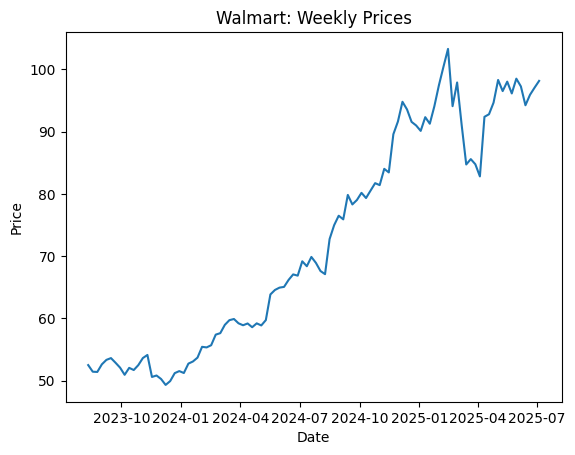

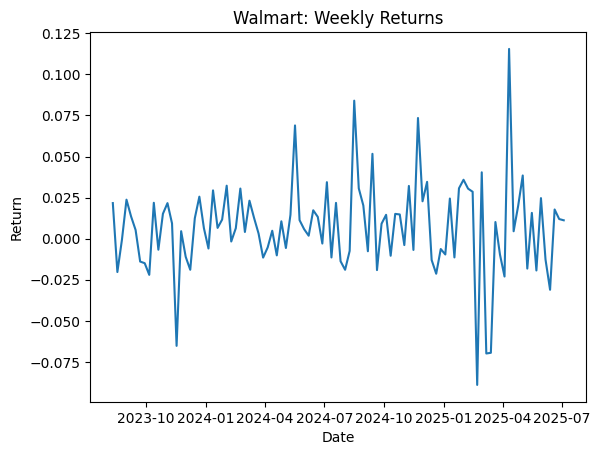


--- Model: CAPM ---


,coef,t-stat
alpha,0.0042,1.7417
MKT_RF,0.6355,4.9366
R^2,0.2513,NaN
Adj R^2,0.2437,NaN


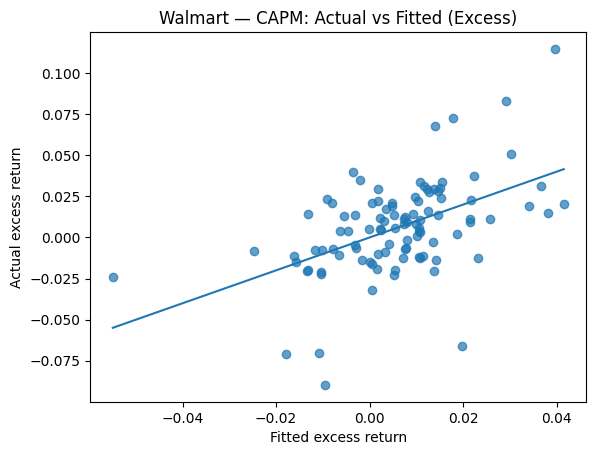


--- Model: FF3 ---


,coef,t-stat
alpha,0.0035,1.3452
MKT_RF,0.6517,4.7962
SMB,-0.2768,-1.9199
HML,-0.0997,-0.5430
R^2,0.2878,NaN
Adj R^2,0.2656,NaN


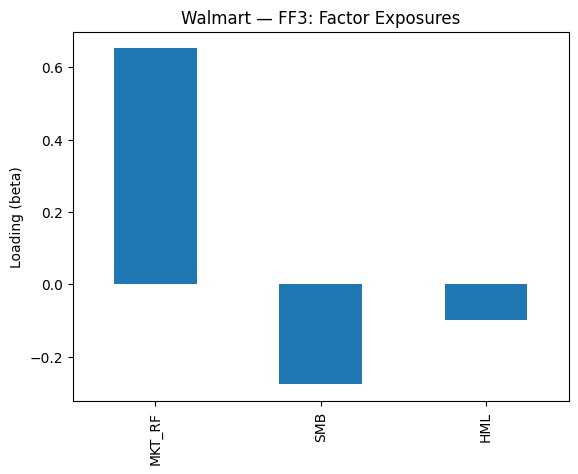


--- Model: FF5 ---


,coef,t-stat
alpha,0.0034,1.2934
MKT_RF,0.6531,4.4425
SMB,-0.2752,-1.9975
HML,-0.0913,-0.4792
RMW,-0.0128,-0.0512
CMA,-0.0732,-0.2248
R^2,0.2883,NaN
Adj R^2,0.2505,NaN


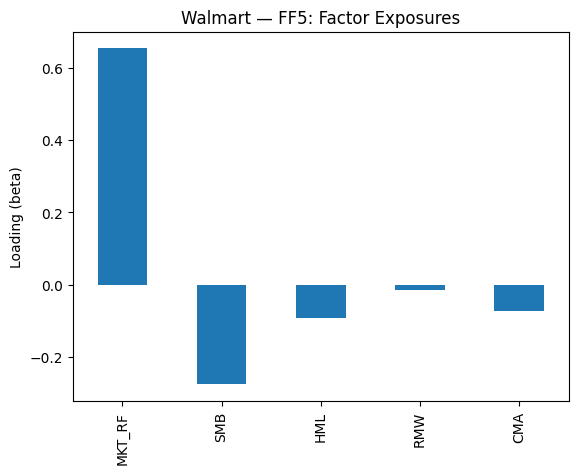


=== Vale (VALE3.SA) ===


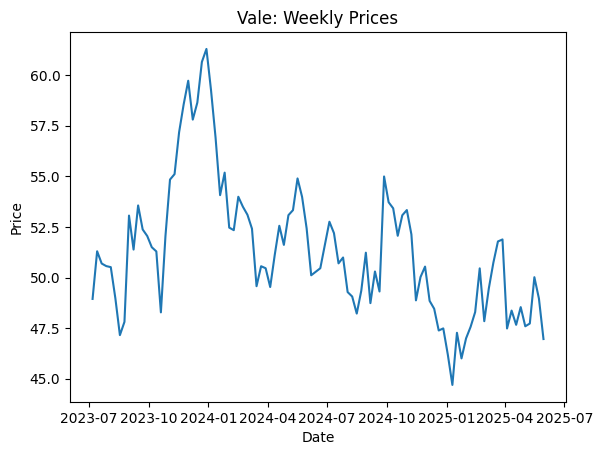

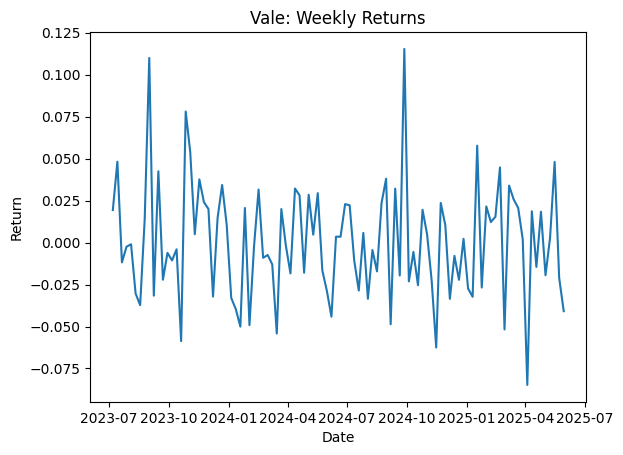


--- Model: CAPM ---


,coef,t-stat
alpha,-0.0015,-0.5811
MKT_RF,0.9794,6.1637
R^2,0.2309,NaN
Adj R^2,0.2231,NaN


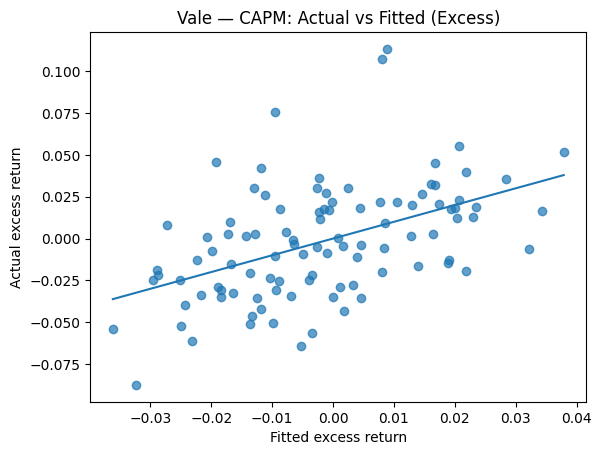


--- Model: FF3 ---


,coef,t-stat
alpha,-0.0030,-1.2207
MKT_RF,0.9488,5.4687
SMB,-0.1278,-0.6511
HML,0.6014,3.0987
R^2,0.2680,NaN
Adj R^2,0.2452,NaN


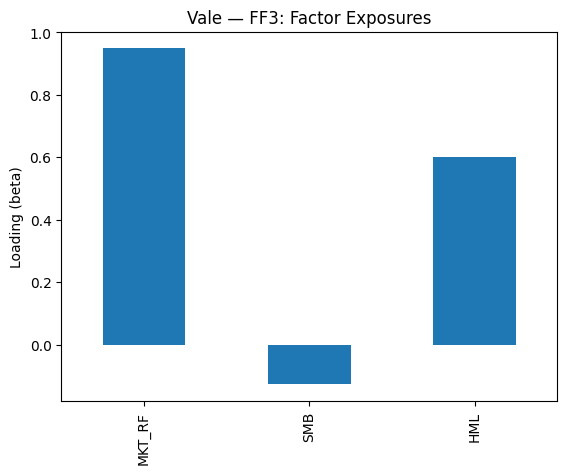


--- Model: NEFIN5 ---


,coef,t-stat
alpha,-0.0035,-1.2218
MKT_RF,0.8764,4.3745
SMB,0.2957,0.6049
HML,0.6911,3.4762
WML,-0.1440,-0.7928
IML,-0.6934,-1.1725
R^2,0.2886,NaN
Adj R^2,0.2508,NaN


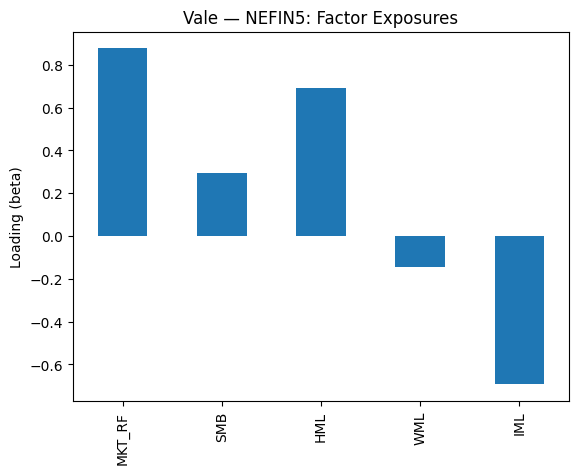


=== Petrobras (PETR4.SA) ===


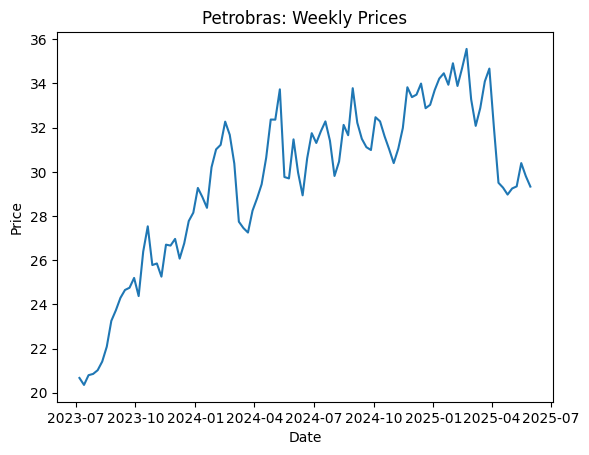

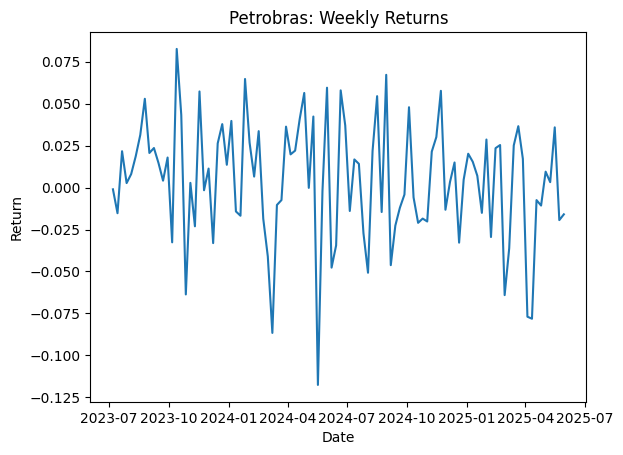


--- Model: CAPM ---


,coef,t-stat
alpha,0.0022,0.6392
MKT_RF,0.6630,4.4676
R^2,0.0947,NaN
Adj R^2,0.0855,NaN


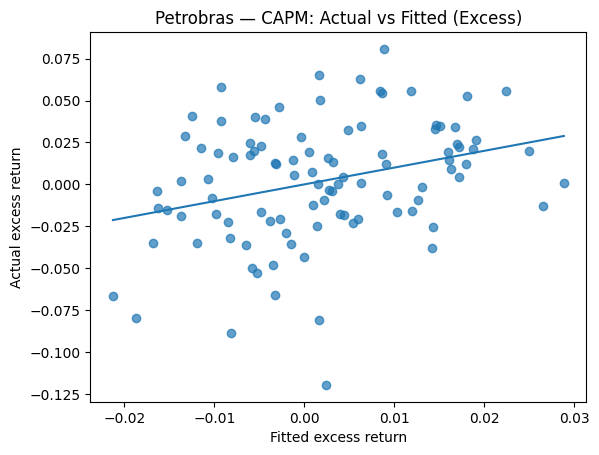


--- Model: FF3 ---


,coef,t-stat
alpha,0.0022,0.6418
MKT_RF,0.7251,4.6383
SMB,-0.2498,-1.2326
HML,-0.0231,-0.0638
R^2,0.1076,NaN
Adj R^2,0.0797,NaN


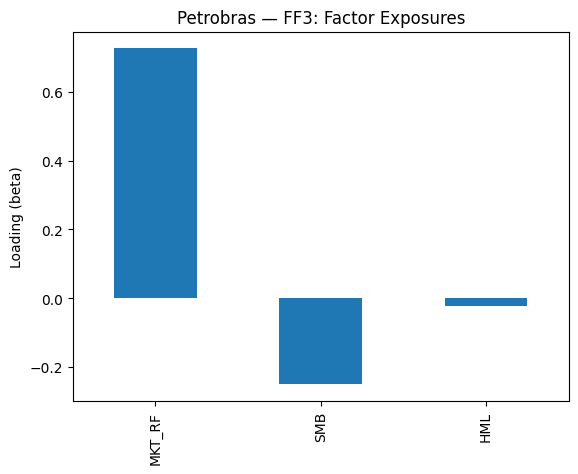


--- Model: NEFIN5 ---


,coef,t-stat
alpha,0.0024,0.6816
MKT_RF,0.7655,5.1441
SMB,-0.4535,-0.9466
HML,-0.0697,-0.1817
WML,0.0856,0.4429
IML,0.3458,0.5524
R^2,0.1125,NaN
Adj R^2,0.0653,NaN


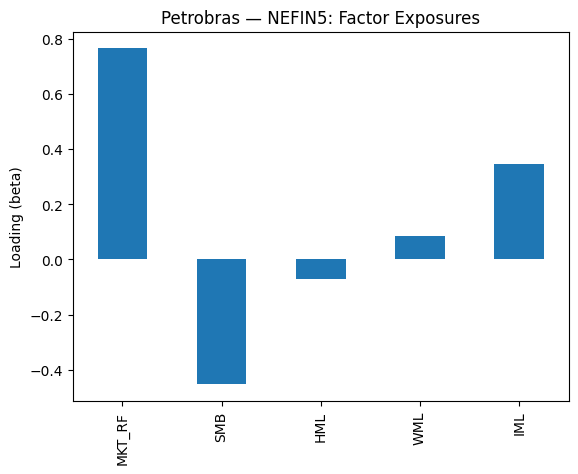


=== BTG Pactual (BPAC11.SA) ===


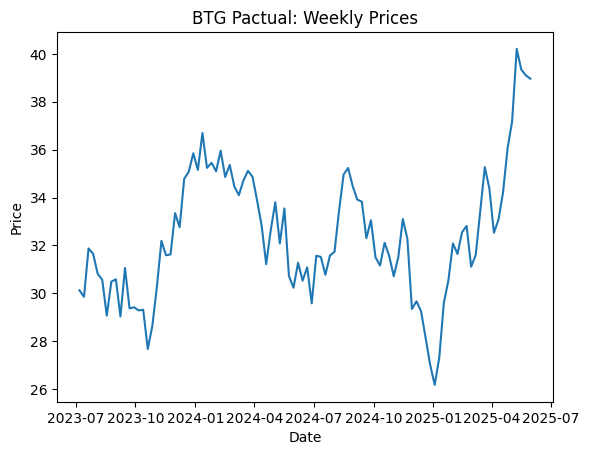

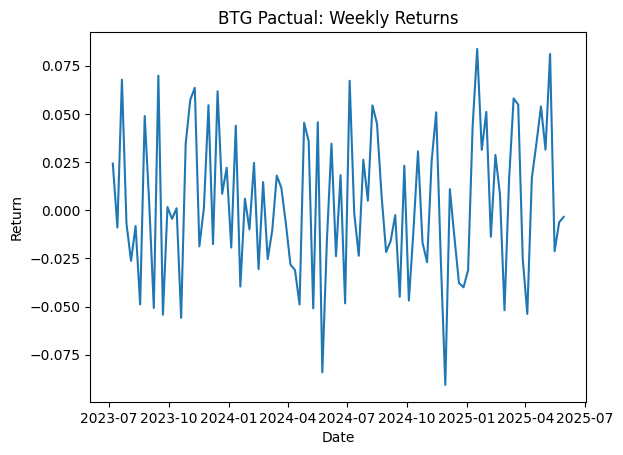


--- Model: CAPM ---


,coef,t-stat
alpha,0.0018,0.9160
MKT_RF,1.5948,10.5642
R^2,0.4913,NaN
Adj R^2,0.4861,NaN


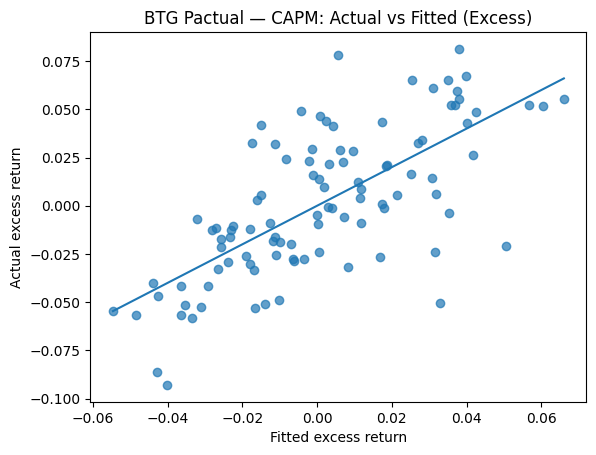


--- Model: FF3 ---


,coef,t-stat
alpha,0.0028,1.2759
MKT_RF,1.5573,9.0387
SMB,0.3074,2.7656
HML,-0.3545,-1.1914
R^2,0.5124,NaN
Adj R^2,0.4971,NaN


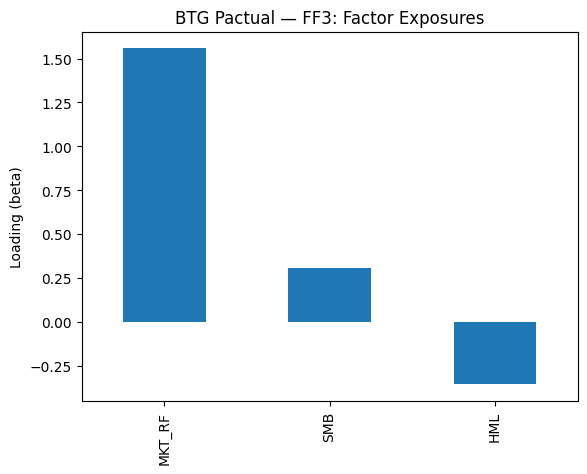


--- Model: NEFIN5 ---


,coef,t-stat
alpha,0.0024,1.1592
MKT_RF,1.6318,8.8893
SMB,0.3494,0.9241
HML,-0.3972,-1.2770
WML,0.2258,1.2239
IML,0.1130,0.2436
R^2,0.5206,NaN
Adj R^2,0.4951,NaN


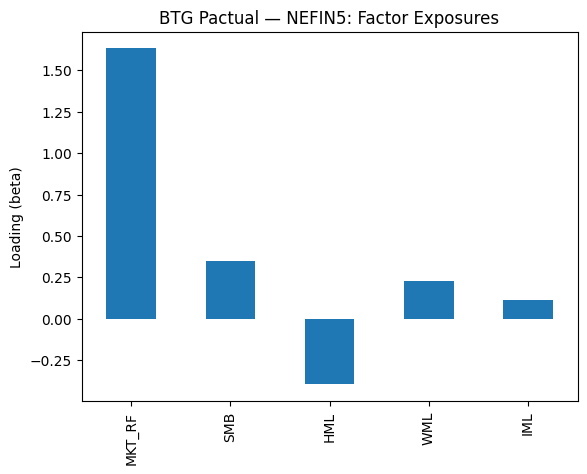


=== Inter (INBR32.SA) ===


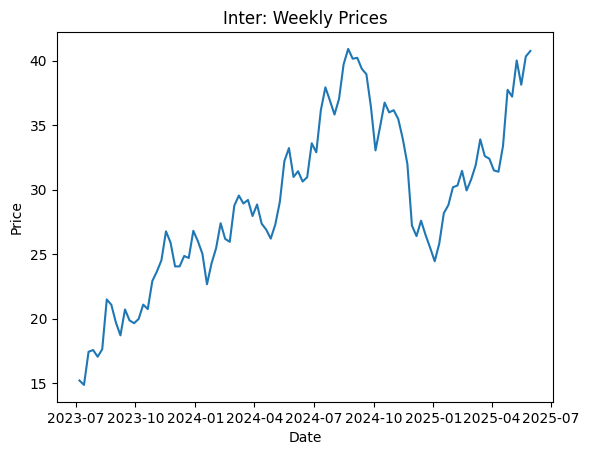

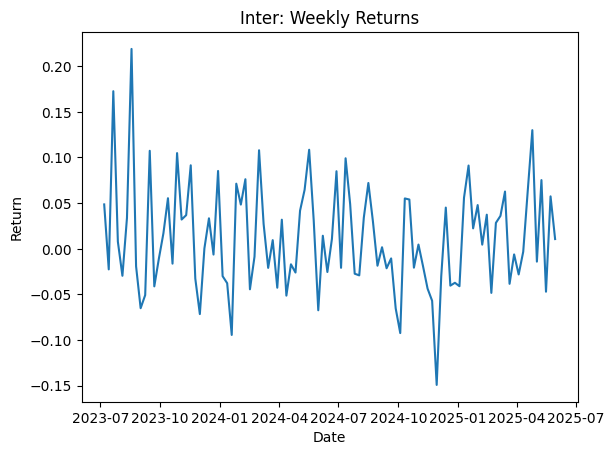


--- Model: CAPM ---


,coef,t-stat
alpha,0.0102,1.9936
MKT_RF,1.1752,3.4856
R^2,0.1125,NaN
Adj R^2,0.1035,NaN


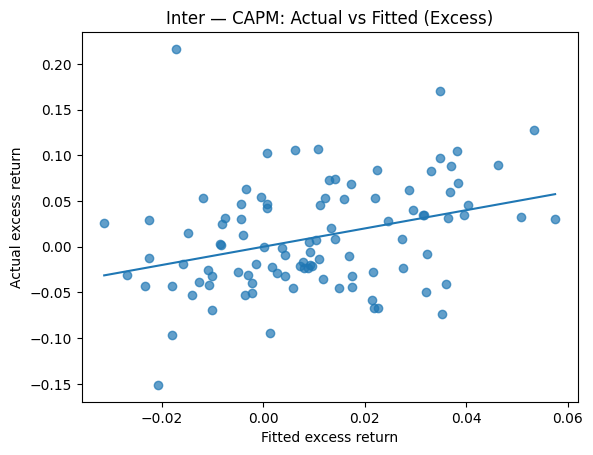


--- Model: FF3 ---


,coef,t-stat
alpha,0.0086,1.7835
MKT_RF,1.2404,3.7711
SMB,-0.5357,-1.7680
HML,0.6192,1.3170
R^2,0.1395,NaN
Adj R^2,0.1126,NaN


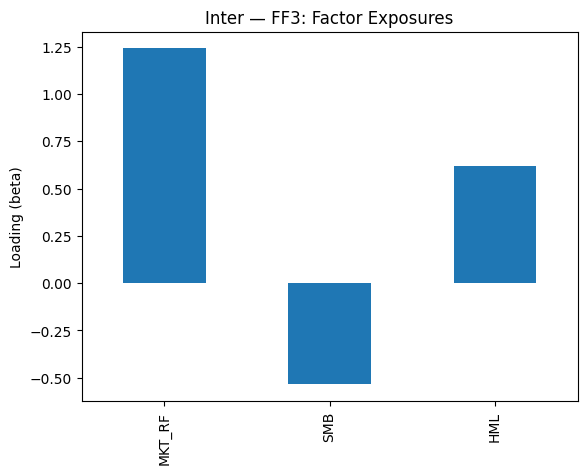


--- Model: NEFIN5 ---


,coef,t-stat
alpha,0.0100,2.0570
MKT_RF,1.1578,2.8846
SMB,-1.1939,-2.0781
HML,0.6031,1.2123
WML,-0.3497,-0.9329
IML,0.6433,0.9512
R^2,0.1517,NaN
Adj R^2,0.1066,NaN


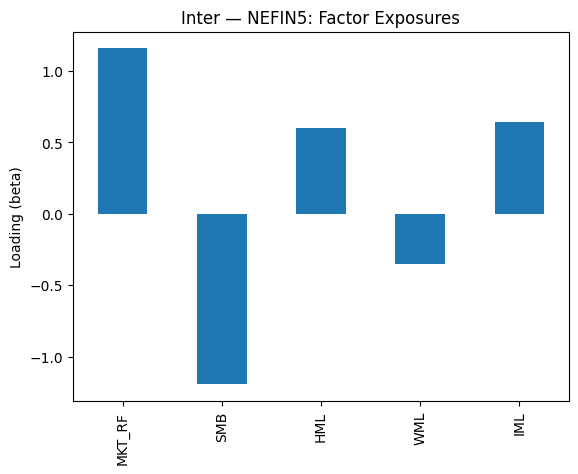

In [ ]:

def show_stock_results(stock_name: str, ticker: str, models_dict: dict,
                       prices_daily: pd.Series, returns_weekly: pd.Series):
    print(f"\n=== {stock_name} ({ticker}) ===")
    # Determine the regression sample index from the first model (or fallback to last SAMPLE_WEEKS of returns)
    if models_dict:
        first_key = next(iter(models_dict))
        sample_idx = models_dict[first_key][1].index  # y index
    else:
        sample_idx = returns_weekly.index[-SAMPLE_WEEKS:]

    # FIRST plot price series and returns series
    plot_prices_weekly(prices_daily, sample_idx, f"{stock_name}: Weekly Prices", WEEKLY_RULE)
    plot_returns_weekly(returns_weekly, sample_idx, f"{stock_name}: Weekly Returns")

    # Then loop models and render tables + allowed plots
    for mname, (res, y, X) in models_dict.items():
        print(f"\n--- Model: {mname} ---")
        tbl = summarize_result(res)
        display(tbl)
        if mname == "CAPM":
            # No exposure bar for CAPM; show actual vs fitted
            fitted = res.fittedvalues
            plot_actual_vs_fitted(y.loc[fitted.index], fitted, f"{stock_name} — {mname}: Actual vs Fitted (Excess)")
        else:
            # Multifactor: show exposure bar; no actual vs fitted
            plot_exposures_bar(res, f"{stock_name} — {mname}: Factor Exposures")

# US results
for stock_name, ticker in us_ok.items():
    if ticker in us_ret_weekly.columns and ticker in us_prices_daily.columns:
        show_stock_results(stock_name, ticker, us_results.get(stock_name, {}),
                           us_prices_daily[ticker].dropna(), us_ret_weekly[ticker].dropna())

# BR results
for stock_name, ticker in br_ok.items():
    if ticker in br_ret_weekly.columns and ticker in br_prices_daily.columns:
        show_stock_results(stock_name, ticker, br_results.get(stock_name, {}),
                           br_prices_daily[ticker].dropna(), br_ret_weekly[ticker].dropna())



## Takeaways & discussion

- **Alpha** near zero and insignificant → the factors explain the stock's average excess return.  
- **Betas** reflect economic exposures (e.g., positive SMB means small-cap tilt; positive HML means value tilt).  
- **R²** increases as we add relevant factors; **adjusted R²** penalizes unnecessary complexity.  
